# Análisis Exploratorio de Datos (EDA)
Los datos ya han sido ingeridos y procesados para su análisis. En este notebook, se prentenden contestar las siguientes preguntas relacionadas al contenido de los mensajes del grupo personal seleccionado: 

* __1. ¿Cuál es el usuario que más mensajes envía?__
* __2.¿Cual es la frecuencia promedio de palabras por mensaje de texto de cada usuario?__
* __3.¿Cuál es el usuario que más palabras envía? ¿Y el que envía más *stickers*?__
* __4.¿Que días de la semana se mandan más mensajes y cuales menos? ¿Hay un patron semanal? ¿Y por hora del día?__
* __5.¿Que palabras son las más usadas por cada usuario? ¿Y en general? ¿Que palabras son las más usadas en el grupo que no sean *stop words*?__
* __6.¿Cuales son los adjetivos más usados?__



In [2]:
# Importar librerias 
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Definir la ruta donde se encuentra el archivo .csv
ruta = os.path.join('..', 'data', 'processed', 'datos_procesados.csv')

# Definir dataframe con parse_dates['timestamp'] para que la columna timestamp tenga formato
df = pd.read_csv(ruta, index_col=0, parse_dates=['timestamp'])

# Verificar dtypes
#df['year'] = df['timestamp'].dt.year
print(df.dtypes)

# Filtrar mensajes del año 2026
df = df[(df['timestamp'] >= '2026-01-01 00:00:00') & (df['timestamp'] <= '2026-12-31 00:00:00')]
df.head(3)

timestamp         datetime64[us]
personaje                    str
contenido                    str
tipo_contenido               str
dtype: object


,timestamp,personaje,contenido,tipo_contenido
62391,2026-01-01 00:06:00,Lord Farquad,Feliz año,texto
62392,2026-01-01 00:06:00,Lord Farquad,‎STK-20251028-WA0004.was (archivo adjunto),sticker
62393,2026-01-01 00:09:00,Burro,FELIZ AÑO chavales,texto


### __1. ¿Cuál es el usuario que más mensajes envía?__

In [3]:
# Guardar una copia del df original
df_pregunta1 = df.copy()

# Crear una columna con el mes
df_pregunta1['mes'] = df['timestamp'].dt.month

# Cambiar nombres de columna
diccionario_meses = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio', 7:'Julio', 8:'Agosto', 9: 'Septiembre', 10:'Octubre', 11:'Noviembre'}
, 12:'Diciembre'}
df_pregunta1['mes'] = df_pregunta1['mes'].map(diccionario_meses)

# Agrupar los datos por personaje y mes y contar el numero de mensajes que tiene cada unuo
df_pregunta1_2026 = df_pregunta1.groupby(['personaje'])['contenido'].count().reset_index(name='Numero de Mensajes')
df_pregunta1_mes = df_pregunta1.groupby(['personaje','mes'])['contenido'].count().reset_index(name='Numero de Mensajes')

# Ordenar por numero de mensajes
df_pregunta1_2026.sort_values(by='Numero de Mensajes', inplace=True)

df_pregunta1_mes.head()

,personaje,mes,Numero de Mensajes
0,Burro,Abril,317
1,Burro,Agosto,637
2,Burro,Enero,380
3,Burro,Febrero,184
4,Burro,Julio,603


C:\Users\victo\AppData\Local\Temp\ipykernel_20920\442807522.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pregunta1_2026, x="personaje", y="Numero de Mensajes", ax=ax[0], palette="PuBuGn", errorbar=None)


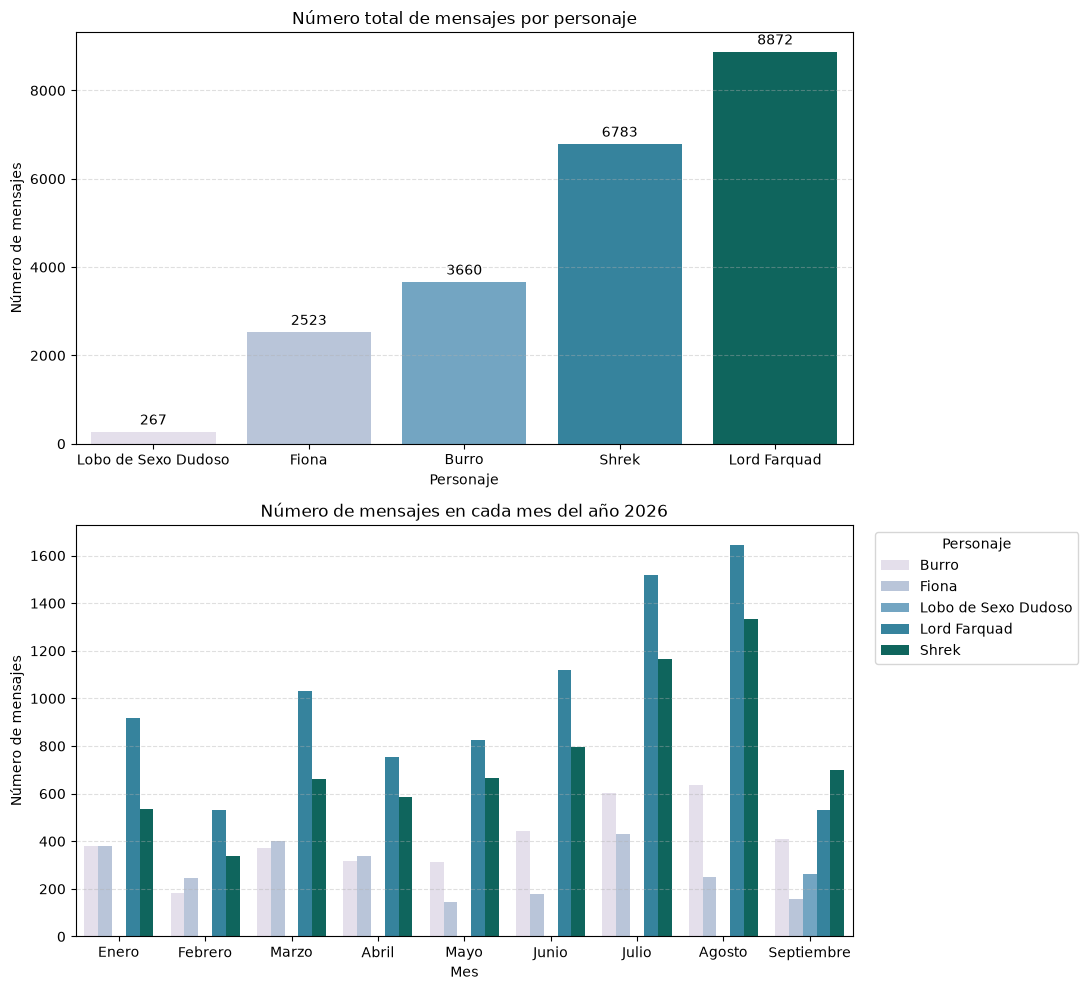

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir una sola figura con 2 subplots verticales 
fig, ax = plt.subplots(2, 1, figsize=(11, 10))

# Gráfoca 1: Total de mensajes por personaje durante lo que va del 2026
sns.barplot(data=df_pregunta1_2026, x="personaje", y="Numero de Mensajes", ax=ax[0], palette="PuBuGn", errorbar=None)
ax[0].set_title("Número total de mensajes por personaje", fontsize=12)
ax[0].set_xlabel("Personaje")
ax[0].set_ylabel("Número de mensajes")
ax[0].tick_params(axis="x")

# Gráfica 2: mensajes de cada personaje por año

sns.barplot(data=df_pregunta1_mes, x="mes", y="Numero de Mensajes", hue="personaje",ax=ax[1], palette="PuBuGn", order=['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembre'])
ax[1].set_title("Número de mensajes en cada mes del año 2026", fontsize=12)
ax[1].set_xlabel("Mes")
ax[1].set_ylabel("Número de mensajes")

# Mover la leyenda afuera de la gráfica (a la derecha) para que no tape las barras
sns.move_legend(ax[1], "upper left", bbox_to_anchor=(1.02, 1), title="Personaje")

# Añadir valor en las barras
for container in ax[0].containers:
  ax[0].bar_label(container, padding=3)

# Definir cuadricula

ax[0].grid(True, axis="y", linestyle="--", alpha=0.4)
ax[1].grid(True, axis="y", linestyle="--", alpha=0.4)

# Ajustar espaciado entre subplots para evitar superposiciones
plt.tight_layout()
plt.show()

El usuario que más mensajes ha enviado en todos los años ha sido Lord Farquad. 

### __2.¿Cual es la frecuencia promedio de palabras por mensaje de texto de cada usuario?__

             personaje  promedio_palabras  mediana_palabras  total_palabras
0                Burro           4.852715               4.0            3517
1                Fiona           4.206237               3.0            2405
2  Lobo de Sexo Dudoso          26.701887              23.0             265
3         Lord Farquad           4.519411               3.0            8423
4                Shrek           5.276771               4.0            5958


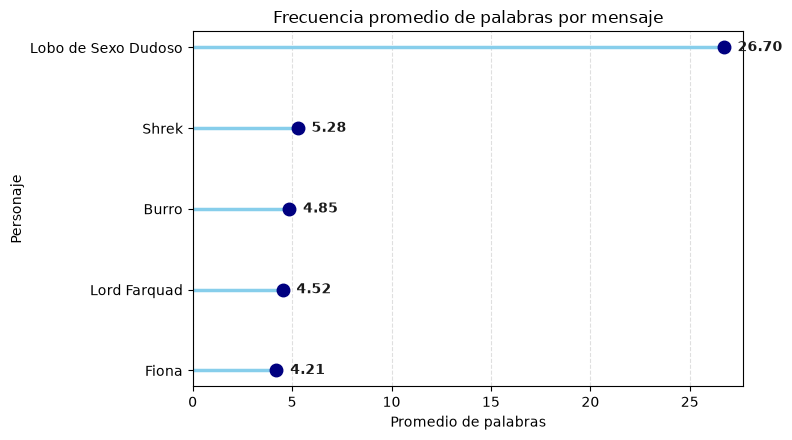

In [5]:
# Importar libreria re para trabajar con expresioner regulares
import re

# Filtrar el df por el tipo de contenido que solo es texto y guardar una dopia en df_texto
df_texto = df[df["tipo_contenido"] == "texto"].copy()

# Crear funcion para contar el numero de palabras dentro de cada mensaje
def conteo_palabras(mensajes):

    # Asegurar que solo se este trabajando con strings
    if not isinstance(mensajes, str):
        return 0
    # Uso de una expresion regular que pueda exxtraer todas las secuencias de palabras
    palabras = re.findall(r"\b[a-záéíóúüñA-ZÁÉÍÓÚÜÑ0-9]+\b", mensajes)
    return len(palabras)

# Aplicar la funcion conteo_palabras al df_texto e incluir una nueva columna que contenga el numero de palabras por por mensaje
df_texto['frecuencia_palabras'] = df_texto['contenido'].apply(conteo_palabras)

# Agrupacion del df para observar la frecuencia promedio, la mediana de frecuencias y el total de frecuencias
df_texto_agrupado = (df_texto.groupby("personaje").agg(promedio_palabras=("frecuencia_palabras", "mean"), 
                                      mediana_palabras=("frecuencia_palabras", "median"),
                                      total_palabras=("frecuencia_palabras", "count")).reset_index())
print(df_texto_agrupado)



# Asegurar orden descendente por promedio
df_sorted = df_texto_agrupado.sort_values("promedio_palabras", ascending=True)

# Definir la figura y el eje
plt.style.use('seaborn-v0_8-pastel')
fig, ax = plt.subplots(figsize=(8, 4.5))


# Dibujar la línea horizontal (tallo) y el punto final
ax.hlines(
    y=df_sorted["personaje"],
    xmin=0,
    xmax=df_sorted["promedio_palabras"],
    color="skyblue",
    linewidth=2.5,
)

# Dibujar los puntos 
ax.plot(df_sorted["promedio_palabras"], df_sorted["personaje"], "o", markersize=9,color="navy")

# Anotar el valor desplazado a la derecha y con letra más pequeña
for _, row in df_sorted.iterrows():
  ax.annotate(f"{row['promedio_palabras']:.2f}",  # Accede al valor de la fila y lo usa como texto
(row["promedio_palabras"], row["personaje"]),  # Punto de anclaje (x, y)
      xytext=(10,0,),  # Desplaza 10 puntos a la derecha sobre el eje X (0 en Y)
      textcoords="offset points",  # Indica que el desplazamiento es en puntos tipográficos
      va="center",  # Centrado vertical
      fontsize=10,  # Tipografía más pequeña
      fontweight="bold",
      color="#1a1a1a")

ax.set_title("Frecuencia promedio de palabras por mensaje", fontsize=12)
ax.set_xlabel("Promedio de palabras")
ax.set_ylabel("Personaje")
ax.set_xlim(0, df_sorted["promedio_palabras"].max() + 1)
ax.grid(True, axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Debido a que el Lobo de Sexo Dudoso es META AI, el agente de IA de whatsapp, es esperado que sea el personaje con mayor numero de palabras por mensaje. Ahora vamos a hacer el gráfico lollipop eliminando al lobo, para solo comparar a los usuarios uqe son personas. 

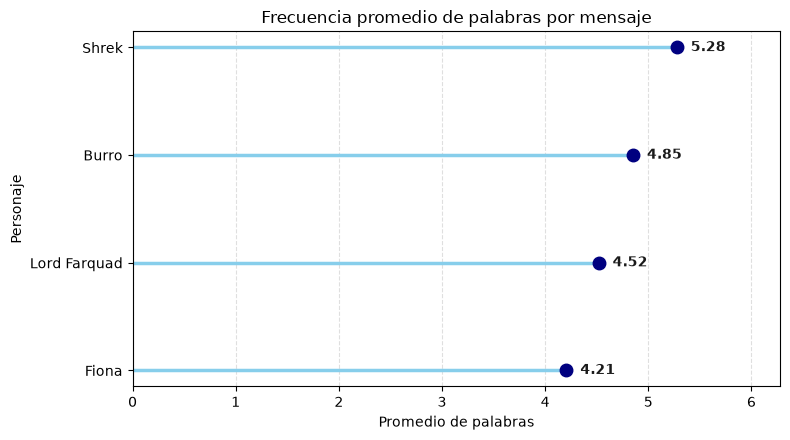

In [6]:
# Eliminar del df al lobo
df_texto_personas = df_texto[~df_texto['personaje'].isin(['Lobo de Sexo Dudoso'])]

# Agrupacion del df para observar la frecuencia promedio, la mediana de frecuencias y el total de frecuencias
df_texto_agrupado = (df_texto_personas.groupby("personaje").agg(promedio_palabras=("frecuencia_palabras", "mean"), 
                                      mediana_palabras=("frecuencia_palabras", "median"),
                                      total_palabras=("frecuencia_palabras", "count")).reset_index())
df_texto_agrupado.round(0)



# Asegurar orden descendente por promedio
df_sorted = df_texto_agrupado.sort_values("promedio_palabras", ascending=True)

# Asegurar orden descendente por promedio
df_sorted = df_texto_agrupado.sort_values("promedio_palabras", ascending=True)

# Definir la figura y el eje
plt.style.use('seaborn-v0_8-pastel')
fig, ax = plt.subplots(figsize=(8, 4.5))

# Dibujar la línea horizontal (tallo) y el punto final
ax.hlines(
    y=df_sorted["personaje"],
    xmin=0,
    xmax=df_sorted["promedio_palabras"],
    color="skyblue",
    linewidth=2.5,
)

# Dibujar los puntos 
ax.plot(df_sorted["promedio_palabras"], df_sorted["personaje"], "o", markersize=9,color="navy")

# Anotar el valor desplazado a la derecha y con letra más pequeña
for _, row in df_sorted.iterrows():
  ax.annotate(f"{row['promedio_palabras']:.2f}",  # Accede al valor de la fila
(row["promedio_palabras"], row["personaje"]),  # Punto de anclaje (x, y)
      xytext=(10,0,),  # Desplaza 10 puntos a la derecha sobre el eje X (0 en Y)
      textcoords="offset points",  # Indica que el desplazamiento es en puntos tipográficos
      va="center",  # Centrado vertical
      fontsize=10,  # Tipografía más pequeña
      fontweight="bold",
      color="#1a1a1a")

ax.set_title("Frecuencia promedio de palabras por mensaje", fontsize=12)
ax.set_xlabel("Promedio de palabras")
ax.set_ylabel("Personaje")
ax.set_xlim(0, df_sorted["promedio_palabras"].max() + 1)
ax.grid(True, axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()



Shrek y Burro son los personajes con mayor frecuencia promedio de palabras, seguidos de Lord Farquad y Fiona. 

### __3.¿Cuál es el usuario que más palabras envía? ¿Y el que envía más *stickers*?__

Para averiguar al personaje que mas palabras envia, vamos a utilizar el df_texto_agrupado creado en el punto anterior. 

      personaje  promedio_palabras  mediana_palabras  total_palabras
1         Fiona           4.206237               3.0            2405
0         Burro           4.852715               4.0            3517
3         Shrek           5.276771               4.0            5958
2  Lord Farquad           4.519411               3.0            8423


C:\Users\victo\AppData\Local\Temp\ipykernel_20920\3507251030.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x="personaje", y="total_palabras",  palette="PuBuGn", errorbar=None)


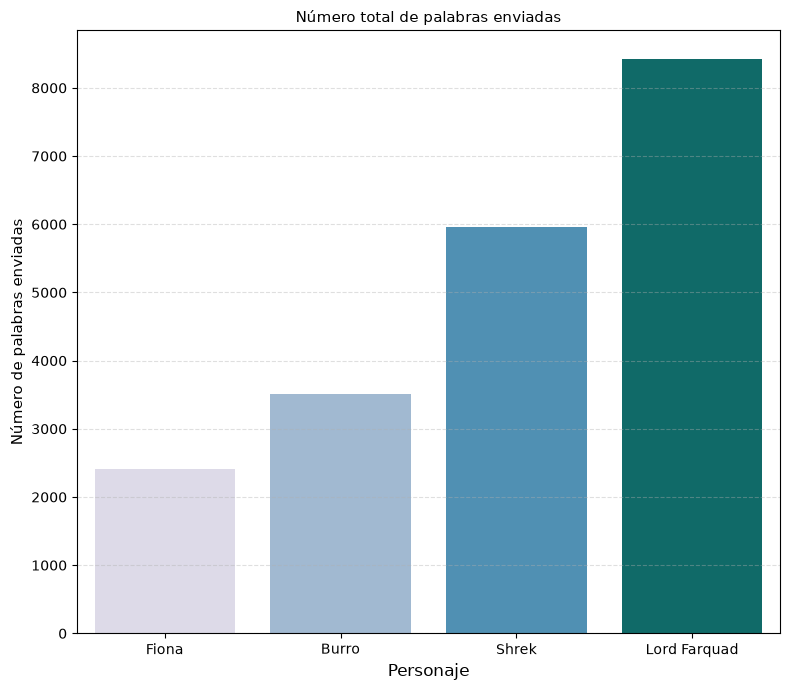

In [7]:
# Asegurar orden descendente por promedio
df_sorted = df_texto_agrupado.sort_values("total_palabras", ascending=True)
print(df_sorted)

# Definir figura
fig, ax = plt.subplots(figsize=(8, 7))

# Definir grafico de barras
sns.barplot(data=df_sorted, x="personaje", y="total_palabras",  palette="PuBuGn", errorbar=None)
ax.set_title("Número total de palabras enviadas", fontsize=11)
ax.set_xlabel("Personaje", fontsize=12)
ax.set_ylabel("Número de palabras enviadas", fontsize=11)
ax.tick_params(axis="x")

# Definir cuadricula
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

# Ajustar espaciado entre subplots para evitar superposiciones
plt.tight_layout()
plt.show()

Para averiguar al usuario que envia mas stickers, se filtrará el df según el tipo de contenido, el cual se encuentra en la columna tipo_contenido.

In [8]:
# Filtrar dataframe por tipo de contenido que sea igual a sticker
df_sticker = df[df['tipo_contenido'] == 'sticker']

# Mostrar stickers enviados por personajes 
df_sticker['personaje'].value_counts().reset_index(name='stickers_totales_enviados').sort_values(by='stickers_totales_enviados', ascending=False)


,personaje,stickers_totales_enviados
0,Shrek,141
1,Burro,113
2,Lord Farquad,102
3,Fiona,94


El usuario que mas stickers envia al grupo (definido por el fomarto .webp o los caracteres stk-) es Shrek, seguido de burro. 

### __4.¿Que días de la semana se mandan más mensajes y cuales menos? ¿Hay un patron semanal? ¿Y por hora del día?__

In [9]:
# Copiar fechas
df_fechas = df.copy()

# Añadir columnas al df con los nombres de la semana y la hora
df_fechas["dia_num"] = df_fechas["timestamp"].dt.dayofweek
df_fechas["hora"] = df_fechas["timestamp"].dt.hour

# Cambiar nombres de la semana al español mapeando los dias
dias_mapa = {0: "Lunes",1: "Martes",2: "Miércoles",3: "Jueves",4: "Viernes",5: "Sábado", 6: "Domingo"}
df_fechas["dia_semana"] = df_fechas["dia_num"].map(dias_mapa)
orden_semana = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]

# Agrupar por dia de la semana
resumen_dias = (df_fechas.groupby(["dia_num", "dia_semana"]).size().reset_index(name="total_mensajes").sort_values("dia_num"))

# Agrupar por hora
resumen_horas = (df_fechas.groupby(['hora']).size().reset_index(name='total_mensajes').sort_values('hora'))
resumen_dias.head()

,dia_num,dia_semana,total_mensajes
0,0,Lunes,3268
1,1,Martes,2634
2,2,Miércoles,2695
3,3,Jueves,4284
4,4,Viernes,3680


In [10]:
# obtener la fila  con el dia que tiene mas mensajes
fila_mas_mensajes = resumen_dias.loc[resumen_dias['total_mensajes'].idxmax()]
# Obtener el dia con mas mensajes
dia_mas_mensajes = fila_mas_mensajes['dia_semana']


# obtener la fila con el dia que tiene menos mensajes
fila_menos_mensajes = resumen_dias.loc[resumen_dias['total_mensajes'].idxmin()]
# Dia con menos mensajes
dia_menos_mensajes = fila_menos_mensajes['dia_semana']

# Obtener la fila de la hora en la que se envian mas mensajes
fila_hora_mas_mensajes = resumen_horas.loc[resumen_horas['total_mensajes'].idxmax()]
# hora con mas mensajes
hora_mas_mensajes = int(fila_hora_mas_mensajes['hora'])


# Obtener la fila de la hora en la que se envian mas mensajes
fila_hora_mas_mensajes = resumen_horas.loc[resumen_horas['total_mensajes'].idxmin()]
# hora con mas mensajes
hora_menos_mensajes = int(fila_hora_mas_mensajes['hora'])

# Contestar preguntas puntuales
print(f'Día de la semana que se envían MÁS mensajes: {dia_mas_mensajes}\n')
print(f'Día de la semana que se envían MENOS mensajes: {dia_menos_mensajes}\n')
print(f'Hora de la semana que se envían MÁS mensajes: {hora_mas_mensajes}h\n')
print(f'Hora de la semana que se envían MENOS mensajes: {hora_menos_mensajes}h\n')

Día de la semana que se envían MÁS mensajes: Jueves

Día de la semana que se envían MENOS mensajes: Martes

Hora de la semana que se envían MÁS mensajes: 18h

Hora de la semana que se envían MENOS mensajes: 2h



C:\Users\victo\AppData\Local\Temp\ipykernel_20920\1438860064.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_dias, x='dia_semana', y='total_mensajes', ax=ax, palette='Blues_d')


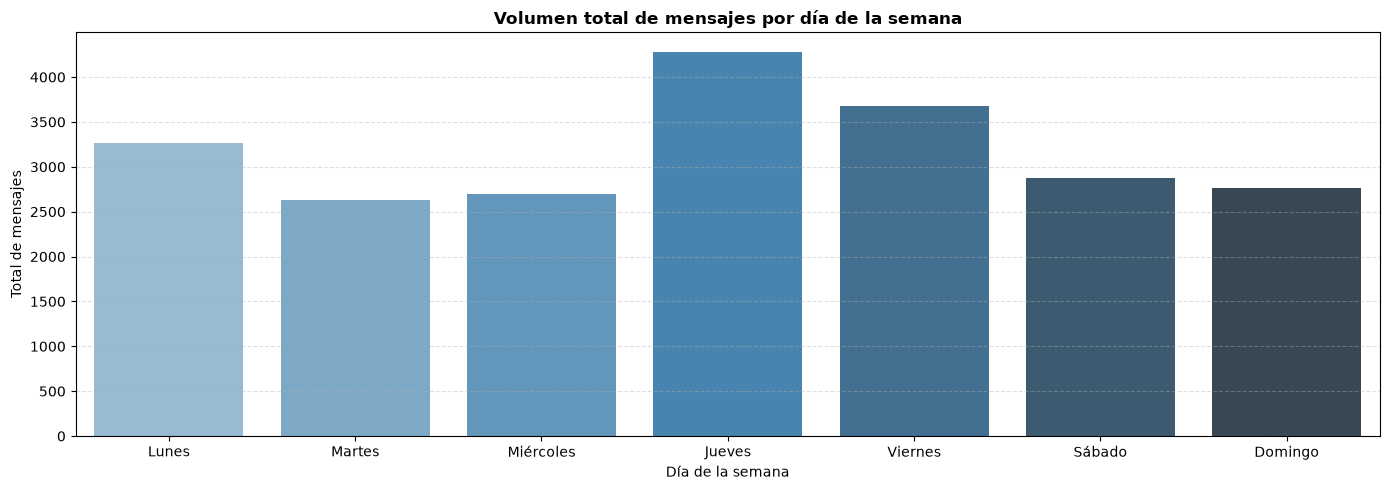

In [11]:
# Crear grafica para mostrar el patron semanal de mensajes
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=resumen_dias, x='dia_semana', y='total_mensajes', ax=ax, palette='Blues_d')

ax.set_title("Volumen total de mensajes por día de la semana", fontsize=12, fontweight="bold")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Total de mensajes")
ax.tick_params(axis="x")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

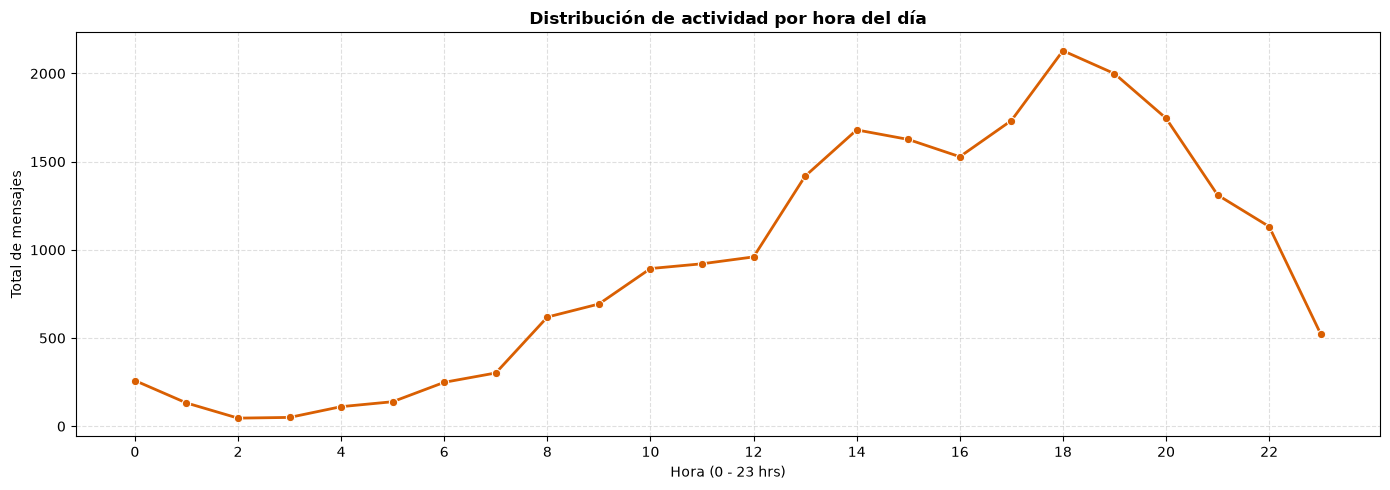

<Figure size 640x480 with 0 Axes>

In [12]:
# Crear grafica para mostrar el patron de mensajes por hora
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=resumen_horas, x='hora', y='total_mensajes', marker='o', color="#d95f02", linewidth=2, ax=ax)
ax.set_title("Distribución de actividad por hora del día", fontsize=12, fontweight="bold")
ax.set_xlabel("Hora (0 - 23 hrs)")
ax.set_ylabel("Total de mensajes")
ax.set_xticks(range(0, 24,2))
ax.grid(True, linestyle="--", alpha=0.4)

# Ajuste visual para evitar recortes
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### __5.¿Que palabras son las más usadas por cada usuario? ¿Y en general? ¿Que palabras son las más usadas en el grupo que no sean *stop words*?__

Para poder analizar esta parte, utilizaremos la libreria spaCy, la cual permite analizar textos a través de tokens. 

In [69]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
import pandas as pd

# Cargar las stop words estándar en español de NLTK
stop_words_es = set(stopwords.words("spanish"))

# Crear un diccionario personal para incorporar stop words
palabras_a_ignorar = {
    # Residuos de enlaces e hipervínculos
    "https",
    "http",
    "www",
    "com",
    "instagram",
    "reel",
    "reels",
    "igsh",
    "youtu",
    "youtube",
    "tiktok",
    # Personajes / personas anonimizadas
    "shrek",
    "lord",
    "farquad",
    "burro",
    "fiona",
    "lobo",
    "sexo",
    "dudoso",
    "efrén",
    "efren",
    # Modismos y slang
    "we",
    "wey",
    "alv",
    "alb",
    "qp",
    "bro",
    "verga",
    "vrga",
    "vergas",
    "tmb",
    "sii",
    "siii",
    "simon",
    "ptm",
    # Textos de exportación de WhatsApp
    "mensaje",
    "mensajes",
    "eliminó",
    "elimino",
    "multimedia",
    "omitido",
    "archivo",
    "sticker",
    "stickers",
    "imagen",
    "audio",
    "video",
    "llamada",
    "perdida",
    # Monosílabos / respuestas cortas
    "si",
    "sí",
    "no",
    "ok",
    "va",
}

# Unir ambas listas en un único conjunto
todas_stop_words = stop_words_es.union(palabras_a_ignorar) # con .union uniremos dos sets


# Función de extracción y limpieza por mensaje
def limpiar_con_nltk(texto):
  texto = str(texto).lower()
  # Eliminar URLs completas (http, https, www y enlaces de dominios)
  texto = re.sub(r"https?://\S+|www\.\S+", "", texto) #con re.sub podemos sustituir la url 
  texto = re.sub(r"\S+\.(com|org|net|me|co)\S*", "", texto)
  # Eliminar menciones con @ (ej. @lord, @burro)
  texto = re.sub(r"@\S+", "", texto)
  # Eliminar cualquier variación de risas (jaja, jajaja, jajajaj, etc.)
  texto = re.sub(r"\b(j[aeiou]){2,}j?\b", "", texto)

  # Extraer solo palabras alfabéticas con acentos en español (mínimo 2 letras)
  palabras = re.findall(r"\b[a-záéíóúñ]{2,}\b", texto) # En esta parte realizamos la tokenizacion, donde separamos palabra por palabra

  # Conservar únicamente palabras que no estén en la lista de stop words
  return [p for p in palabras if p not in todas_stop_words]


# Filtrar el df original por contenido tipo texto y aplicar la funcion
df_nlp = df[(df["tipo_contenido"] == "texto") & (df["contenido"].notna())].copy()
df_nlp["palabras_limpias"] = df_nlp["contenido"].apply(limpiar_con_nltk)

df_nlp.head()

,timestamp,personaje,contenido,tipo_contenido,palabras_limpias
62391,2026-01-01 00:06:00,Lord Farquad,Feliz año,texto,"[feliz, año]"
62393,2026-01-01 00:09:00,Burro,FELIZ AÑO chavales,texto,"[feliz, año, chavales]"
62394,2026-01-01 00:09:00,Shrek,"Feliz año nuevo, que cojan un chingo🙏🏽❤️",texto,"[feliz, año, nuevo, cojan, chingo]"
62395,2026-01-01 00:21:00,Fiona,Feliz año chavales!’n,texto,"[feliz, año, chavales]"
62396,2026-01-01 00:32:00,Lord Farquad,Provecho,texto,[provecho]


In [72]:
# 5. Top 15 General limpio
todas_las_palabras = [palabra for sublista in df_nlp["palabras_limpias"] for palabra in sublista]
df_top_general = pd.DataFrame(Counter(todas_las_palabras).most_common(20), columns=["Palabra", "Frecuencia"])

display(df_top_general)

,Palabra,Frecuencia
0,bien,347
1,mas,232
2,solo,231
3,hoy,224
4,gym,209
5,asi,192
6,voy,174
7,ver,168
8,ir,161
9,pues,152


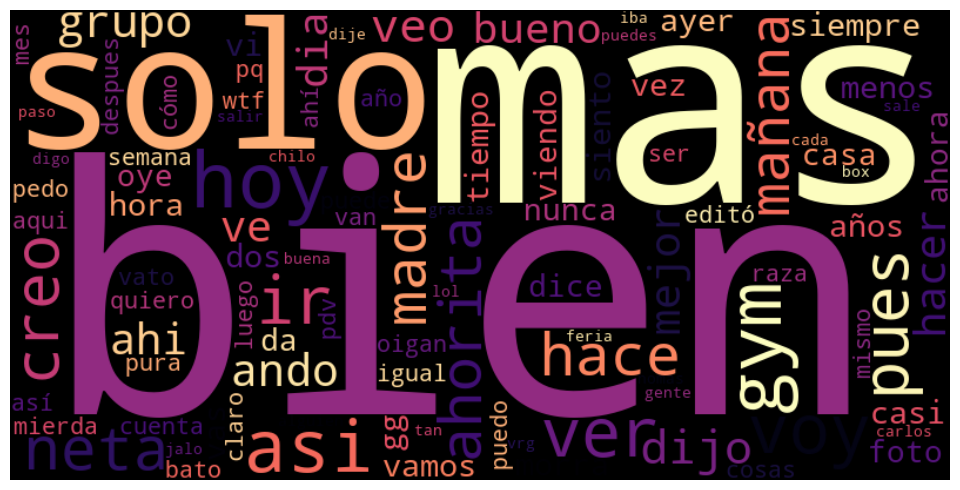

In [68]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
conteo_general = Counter(todas_las_palabras) 
# 1. Crear el objeto WordCloud a partir de las frecuencias calculadas
# (dict(conteo_general) toma tus palabras y sus repeticiones ya limpias)
wc = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="magma", 
    max_words=100,  # Máximo de palabras a mostrar
).generate_from_frequencies(dict(conteo_general))

# 2. Desplegar la imagen con Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")  # Oculta los ejes numéricos
plt.tight_layout()
plt.show()

In [74]:
from collections import Counter
import re
import pandas as pd
import spacy

# 1. Cargar spaCy con el analizador sintáctico para que el contexto sea más preciso
nlp = spacy.load("es_core_news_sm", disable=["ner"])

# 2. Filtrar textos válidos
df_mensajes = df[
    (df["tipo_contenido"] == "texto") & (df["contenido"].notna())
].copy()


# 3. Limpiar residuos antes de pasárselo a spaCy
def limpiar_antes_de_spacy(texto):
  texto = str(texto)
  texto = re.sub(r"https?://\S+|www\.\S+", "", texto)  # URLs
  texto = re.sub(r"@\S+", "", texto)  # @menciones
  texto = re.sub(r"\b(j[aeiou]){2,}j?\b", "", texto, flags=re.IGNORECASE)  # Risas
  return texto.strip()


df_mensajes["texto_para_pos"] = df_mensajes["contenido"].apply(
    limpiar_antes_de_spacy
)

# 4. Palabras que el modelo suele confundir con adjetivos en chats informales
falsos_adjetivos = {
    "ahorita",
    "mierda",
    "verga",
    "wey",
    "we",
    "alv",
    "qp",
    "bro",
    "lobo",
    "shrek",
    "burro",
    "fiona",
    "farquad",
    "efren",
    "efrén",
}

# 5. Extraer únicamente adjetivos legítimos
adjetivos_reales = []

for doc in nlp.pipe(
    df_mensajes["texto_para_pos"][df_mensajes["texto_para_pos"] != ""],
    batch_size=1000,
):
  for token in doc:
    # Evaluamos etiqueta ADJ, descartamos stop words y el filtro de seguridad
    if (
        token.pos_ == "ADJ"
        and not token.is_stop
        and token.is_alpha
        and len(token.text) > 2
        and token.lemma_.lower() not in falsos_adjetivos
    ):
      # Usar token.lemma_.lower() agrupa 'segura'/'seguro' o 'bueno'/'buena'
      adjetivos_reales.append(token.lemma_.lower())

# 6. Top 10 Adjetivos
df_top_adjetivos = pd.DataFrame(
    Counter(adjetivos_reales).most_common(10),
    columns=["Adjetivo (Lema)", "Frecuencia"],
)

display(df_top_adjetivos)

,Adjetivo (Lema),Frecuencia
0,puro,58
1,real,43
2,anda,26
3,seguro,26
4,rico,22
5,ahorito,21
6,mierdo,21
7,salio,21
8,junto,20
9,rojo,20
